# Tutorial for Running a 3-phase equilibrium calculation with SGTpy:
First make sure the system is properly installed and running. To do so, just install it with the following pip install command. This will also install:

- numpy
- scipy
- cython
- pandas
- numba

We also recomend to install some extra modules to plot:
- matplotlib
- python-ternary



In [1]:
pip install sgtpy matplotlib python-ternary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.1 MB/s eta 0:00:00


# Part 1: VLLE of a LJ mixture
Now we will generate a VLLE curve for a binary LJ mixture. In SGTpy one starts loading the necessary modules and generating a mixture.

We will need:
- The numpy module: to work with arrays
- The "Component, Mixture and SAFTVRMIE" Modules of sgtpy to prepare the mixture
- The "vlleb" module of sgtpy to run the three-phase equilibria for binary mixtures.

Compoments are defined based on a Mie potential, so we define ɛ, σ, λr = 12 and λa = 6. Since we are modeling LJ fluids the chain lenght (ms) is set to 1. We decide to use the same 16 g/mol as molar mass for each molecular fluid.

A crossed-interaction parameter ($k_{ij}$) can be included in array form to modify the interactions according to:

$\varepsilon_{ij}=\sqrt{\varepsilon_i \varepsilon_j}\frac{\sqrt{\sigma_i^3 \sigma_j^3}}{\sigma_{ij}^3}(1-k_{ij})$

where the default $k_{ij} = 0$ recovers the standard interaction geometric mixing rule.

________

In this block, we define each component (with its molecular parameters), create a binary mixture adding both components together, define a $k_{ij}$ array and build the EoS with all those elements

In [28]:
import numpy as np
from sgtpy import component, mixture, saftvrmie
from sgtpy.equilibrium import vlle, vlleb

c1 = component('LJ_1', Mw = 16,  ms = 1, sigma = 3.73, eps = 148.00, lambda_r =  12., lambda_a = 6.0)
c2 = component('LJ_2', Mw = 16,  ms = 1, sigma = 3.73, eps = 200.23, lambda_r = 12., lambda_a = 6.0)

mix = c1 + c2
mix.kij_saft(np.array([[ 0,    0.12 ],
                       [0.12,    0 ]]))
eos = saftvrmie(mix)

Then we calculate the VLLE curve using the Vlleb function. To that end, we look for a initial point that converges and use that as initial guess. Then, we run the Vlleb function in temperature using the previously converged point as initial guess for the following.

Good initial guesses can be generated from different techniques:
- Trial and error
- Pre-converging a low temperature LLE and run up in T until you get close to the 3-phase point
- Pre-converging a VLE from a pure component down in T until you get close to the 3-phase point.



In [24]:
Npoints = 25
x = np.zeros((Npoints,2))
w = np.zeros((Npoints,2))
y = np.zeros((Npoints,2))
rhoX = np.zeros(Npoints)
rhoW = np.zeros(Npoints)
rhoY = np.zeros(Npoints)
P = np.zeros(Npoints)

# Find a point using a manual initial guesses
P[0] = 0.01 * 101325 # Pa
x[0] = np.array([0.96, 0.04])
w[0] = np.array([0.04, 0.96])
y[0] = np.array([0.6, 0.4])
T    = np.linspace(75, 125, Npoints)

# Converge point 0
sol = vlleb(x[0], w[0], y[0], P[0], T[0], 'T', eos, full_output=True)
x[0]=sol.X
y[0]=sol.Y
w[0]=sol.W
P[0]=sol.P
rhoX[0]=1/sol.vx
rhoW[0]=1/sol.vw
rhoY[0]=1/sol.vy

print ("     (K)      (bar)                 (kg/m3)                  (kg/m3)               (kg/m3)")
print ("      T        P        x1    x2     ρ_X        w1    w2      ρ_W       y1    y2    ρ_Y      ")
print ("_________________________________________________________________________________________________________________")
print ("{:<3d} {:.2f}    {:.2f}     {:.3f} {:.3f}  {:.1f}     {:.3f} {:.3f}  {:.1f}    {:.3f} {:.3f}  {:.1f}  ".format(
           0,    T[0],    P[0]/1e5,  x[0,0], x[0,1], rhoX[0], w[0,0], w[0,1], rhoW[0], y[0,0], y[0,1], rhoY[0]))

# Loop from T0 to Tf
for i in range(1, Npoints):
  sol = vlleb(x[i-1], w[i-1], y[i-1], P[i-1], T[i], 'T', eos, full_output=True)
  x[i]=sol.X
  y[i]=sol.Y
  w[i]=sol.W
  P[i]=sol.P
  rhoX[i]=1/sol.vx
  rhoW[i]=1/sol.vw
  rhoY[i]=1/sol.vy

  print ("{:<3d} {:.2f}    {:.2f}     {:.3f} {:.3f}  {:.1f}     {:.3f} {:.3f}  {:.1f}    {:.3f} {:.3f}  {:.1f}  ".format(
           i,    T[i],    P[i]/1e5,  x[i,0], x[i,1], rhoX[i], w[i,0], w[i,1], rhoW[i], y[i,0], y[i,1], rhoY[i]))



     (K)      (bar)                 (kg/m3)                  (kg/m3)               (kg/m3)
      T        P        x1    x2     ρ_X        w1    w2      ρ_W       y1    y2    ρ_Y      
_________________________________________________________________________________________________________________
0   75.00    0.01     0.986 0.014  28855.0     0.014 0.986  30059.4    0.993 0.007  1.8  
1   77.08    0.02     0.983 0.017  28715.5     0.016 0.984  29964.2    0.992 0.008  2.5  
2   79.17    0.02     0.980 0.020  28574.5     0.018 0.982  29867.2    0.991 0.009  3.6  
3   81.25    0.03     0.977 0.023  28431.9     0.021 0.979  29768.2    0.989 0.011  4.9  
4   83.33    0.05     0.974 0.026  28287.7     0.024 0.976  29667.3    0.987 0.013  6.6  
5   85.42    0.06     0.970 0.030  28142.0     0.028 0.972  29564.4    0.986 0.014  8.8  
6   87.50    0.08     0.966 0.034  27994.8     0.031 0.969  29459.5    0.984 0.016  11.6  
7   89.58    0.11     0.961 0.039  27846.0     0.035 0.965  29352.3   

Now plot the binary VLLE curve in a 1x3 multiplot, with:
- Clapeyron diagram (P-T)
- Phase envelope (densities)
- Phase envelope (compositions)

Text(0, 0.5, 'T / K')

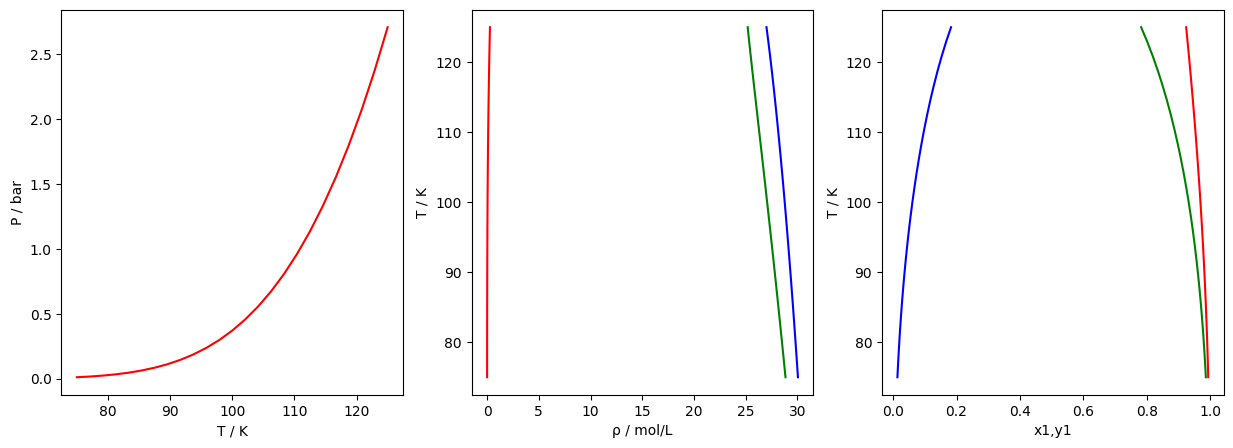

In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(T, P/1e5, 'r')
ax1.set_xlabel('T / K')
ax1.set_ylabel('P / bar')

ax2.plot(rhoX/1000, T, 'g')
ax2.plot(rhoY/1000, T, 'r')
ax2.plot(rhoW/1000, T, 'b')
ax2.set_xlabel('ρ / mol/L')
ax2.set_ylabel('T / K')

ax3.plot(x[:,0], T, 'g')
ax3.plot(y[:,0], T, 'r')
ax3.plot(w[:,0], T, 'b')
ax3.set_xlabel('x1,y1')
ax3.set_ylabel('T / K')


# Part 2: VLLE of a ternary mixture
Now we will generate a VLLE curve for a complex ternary mixture. In SGTpy one starts loading the necessary modules and generating a mixture.

We will need:
- The numpy module: to work with arrays
- The scipy module: to run some optimization routines
- The "Component, Mixture and SAFTVRMIE" Modules of sgtpy to prepare the mixture
- The "vlle" modulee of sgtpy run the three-phase equilibria for ternary mixtures (vlle)
- The "Warnings" module (optional): to supress some unnecessary scipy output and make it cleaner

We import the needed SGTpy modules to build a mixture and model it with SAFT-VR Mie EoS. Here we use the *component* function to load each pure component's SAFT parameters (*i.e.,* $m_{s,i}$, $\sigma_i$, $\varepsilon_i$, $\lambda_r$,$\lambda_a$, $n_{pol}$ and $\mu_{pol}$, the association parameters $\varepsilon_{ii}^{AB}$, $r_{c,ii}^{AB}$, $r_{dc,ii}^{AB}$ and the association scheme sites=[B,P,N])

Then each pure component is combined into a mixture by adding them together as c1 + c2 + c3 into the mix variable, where the binary interaction parameters can be loaded (*i.e.,* $k_{ij}$ matrix and $l_{ij}$ matrix) for associative pairs:

$\varepsilon_{ij}=\sqrt{\varepsilon_i \varepsilon_j}\frac{\sqrt{\sigma_i^3 \sigma_j^3}}{\sigma_{ij}^3}(1-k_{ij})$

$\varepsilon_{ij}^{AB}=\sqrt{\varepsilon_{ii}^{AB} \varepsilon_{jj}^{AB}}(1-l_{ij})$

Finally, the mixture is loaded into the EoS with the *saftvrmie* function and the induced associative parameters are manually placed. For more information about how to set up a a mixture with SGTpy and calculate VLLE we refer the reader to the original GitHub documentation and examples page:

https://github.com/gustavochm/sgtpy

https://github.com/gustavochm/sgtpy/blob/master/examples/

In [30]:
import numpy as np
from sgtpy import component, mixture, saftvrmie
from sgtpy.equilibrium import vlle
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")


c1 = component('water',     Mw = 18.02,  ms = 1.731, sigma = 2.454, eps = 110.85, lambda_r =  8.308, lambda_a = 6.0, eAB = 1991.07, rcAB = 0.5624, rdAB = 0.4, sites = [0,2,2])
c2 = component('butanol2C', Mw = 74.12,  ms = 1.965, sigma = 4.108, eps = 277.89, lambda_r = 10.669, lambda_a = 6.0, eAB = 3300.00, rcAB = 0.2615, rdAB = 0.4, sites = [1,0,1], npol = 1.450, mupol = 1.661)
c3 = component('cpme',      Mw = 100.16, ms = 2.325, sigma = 4.136, eps = 343.91, lambda_r = 14.155, lambda_a = 6.0,                                           sites = [0,0,1], npol = 1.920, mupol = 1.270)

mix = c1 + c2 + c3
mix.kij_saft(np.array([[ 0,        -0.00736,    -0.01606 ],
                       [-0.00736,   0,           0.00130 ],
                       [-0.01606,   0.00130,     0 ]]))
mix.lij_saft(np.array([[0,         -0.00737,     0],
                       [-0.00737,   0,           0],
                       [0,          0,           0]]))

eos = saftvrmie(mix)
eos.eABij[2,0], eos.eABij[0,2] = c1.eAB/2, c1.eAB/2
eos.eABij[2,1], eos.eABij[1,2] = c2.eAB/2, c2.eAB/2
eos.rcij[2,0],  eos.rcij[0,2]  = 2.646 * 1e-10, 2.646 * 1e-10
eos.rcij[2,1],  eos.rcij[1,2]  = 1.774 * 1e-10, 1.774 * 1e-10

We now calculate the VLLE of the two binary mixtures (i.e., {Water(1) + Butanol(2)} and {Water(1) + CPME(3)}) that serve as initial and final points of the three-phase line with the vlle function.

The vlle function normally performs an isobaric-isothermic multiflash calculation using as initial guesses the composition of the aqueous (
), organic (
) and vapor (
) phases. However, since we are inputting binary compositions the function automatically identifies that only pressure needs to be fixed and finds the temperature and composition of the binary heteroazeotropes. The stability of the phases are automatically checked using the Gibbs tangent plane criterion and the function reports a "success" when it passes the check.

In [31]:
P = 101325
# --------------------------------------------------
# Water (1) + Butanol (2) VLLE at P = 101325
# --------------------------------------------------
T = 360
x0 = np.array([0.99, 0.01, 0])
w0 = np.array([0.60, 0.40, 0])
y0 = np.array([0.80, 0.20, 0])
Z = y0

sol=vlle(x0, w0, y0, Z, T, P, eos, full_output=True)

T12 = sol.T
x12 = sol.X[0]
w12 = sol.X[1]
y12 = sol.X[2]
rhA12 = 1/(1000*sol.v[0]) * np.sum(x12*np.array([c1.Mw, c2.Mw, c3.Mw]))
rhO12 = 1/(1000*sol.v[1]) * np.sum(w12*np.array([c1.Mw, c2.Mw, c3.Mw]))
rhV12 = 1/(1000*sol.v[2]) * np.sum(y12*np.array([c1.Mw, c2.Mw, c3.Mw]))
r12 = sol.success
# --------------------------------------------------
# Water (1) + CPME (3) VLLE at P = 101325
# --------------------------------------------------
T = 360
x0 = np.array([0.99, 0, 0.01])
w0 = np.array([0.01, 0, 0.99])
y0 = np.array([0.60, 0, 0.40])
Z = y0

sol=vlle(x0, w0, y0, Z, T, P, eos, full_output=True)

T13 = sol.T
x13 = sol.X[0]
w13 = sol.X[1]
y13 = sol.X[2]
rhA13 = 1/(1000*sol.v[0]) * np.sum(x13*np.array([c1.Mw, c2.Mw, c3.Mw]))
rhO13 = 1/(1000*sol.v[1]) * np.sum(w13*np.array([c1.Mw, c2.Mw, c3.Mw]))
rhV13 = 1/(1000*sol.v[2]) * np.sum(y13*np.array([c1.Mw, c2.Mw, c3.Mw]))
r13 = sol.success

# --------------------------------------------------

print ("____________________________________________________________________________________________________")
print ("                                 T / K        x1     x2       w1     w2       y1     y2   success")
print ("____________________________________________________________________________________________________")
print (" Water(1) + Butanol(2) [VLLE] -> {:.2f}     {:.3f}  {:.3f}    {:.3f}  {:.3f}    {:.3f}  {:.3f}  {} ".format(T12, x12[0], x12[1], w12[0], w12[1], y12[0], y12[1], r12))
print (" Water(1) + CPME(3)    [VLLE] -> {:.2f}     {:.3f}  {:.3f}    {:.3f}  {:.3f}    {:.3f}  {:.3f}  {} ".format(sol.T,sol.X[0,0], sol.X[0,2],sol.X[1,0], sol.X[1,2],sol.X[2,0], sol.X[2,2], r13))
print ("____________________________________________________________________________________________________")

____________________________________________________________________________________________________
                                 T / K        x1     x2       w1     w2       y1     y2   success
____________________________________________________________________________________________________
 Water(1) + Butanol(2) [VLLE] -> 367.21     0.943  0.057    0.613  0.387    0.775  0.225  True 
 Water(1) + CPME(3)    [VLLE] -> 356.15     0.998  0.002    0.068  0.932    0.524  0.476  True 
____________________________________________________________________________________________________


Then, we loop in temperature from the {Water(1) + Butanol(2)} binary to the {Water(1) + CPME(3)} binary updating the
 linearly from the 1+2 to the 1+3 mixture, so that:


 (this is done with the np.linspace function)

Then, we run an initial vlle function to converge the 1st ternary point with the previously explained isothermic-isobaric multiflash calculation. In ternary mixtures the phase stability is informed in the variable tetha, which reports a stable phase when the three tetha values from L1, L2 and V phases are equal to zero. If all three tethas are zero we consider the VLLE point converged and take its composition as initial guesses for the next point in the iteration.

If any tetha is different from zero we take its
,
 and
 values and try to reconverge it again by setting Z in the center of the
,
 and
 triangle. Once theta is equal zero we proceed to the next data point using the previously converged point.

**Warning: Increase the float lenght in the print functions if data needs to be extracted from this Jupyter-Notebook to plot elsewhere. Here it has been reduced to show all data in a single line**

In [41]:
def vlle_min(zi, xi, wi, yi, Ti, Pi, eos):
     # ------ This function looks for a Z that converges de VLLE -----#
    z3 = 1 - zi[0] - zi[1]      # This constraints z1+z2+z3 = 1
    if z3 <= 0:                 # And corrects the composition if z1+z2 > 1
        z3 = 1e-5               # keeping z1, fixing z3=1e-5 and making z2 to add 1
        zi[1] = 1-zi[0]-z3
    sol = vlle(xi, wi, yi, np.array([zi[0],zi[1],z3]), Ti, Pi, eos, full_output=True)
    #print ("{} {} {} | {:.2e} {:.2e} {:.2e} | {:.2e} {:.2e} {:.2e} {:.3e}".format(zi[0], zi[1], z3, sol.tetha[0],sol.tetha[1],sol.tetha[2], sol.beta[0], sol.beta[1], sol.beta[2], np.sum(sol.tetha**2) ))
    return np.sum(sol.tetha**2)  # We optimize for {FO = Σ θ^2 = 0}

def find_vlle3(x0, w0, y0, z, Ti, Pi, eos):
    # ------ This function calculates the ternary VLLE or it activates the VLLE search -----#
    sol = vlle(x0, w0, y0, z, Ti, Pi, eos, full_output=True)   # We first try to converge with the guess
    z = (sol.X[0]+sol.X[1]+sol.X[2])/3                         # When the guess does not work we get a new guess
    while np.any(sol.tetha != 0):                              # Based on previous VLLE and we try to reconverge it
        print ("-", end="")                                    # If it fails, then we minimize θ with the VLLE_MIN function
        sol = vlle(x0, w0, y0, z, Ti, Pi, eos, full_output=True)
        if np.any(sol.tetha != 0):
            args = (x0, w0, y0, Ti, Pi, eos)
            bnds = ((1e-5, 0.99995), (1e-5, 0.99995))
            if z[0] == 0:         # If 2+3 binary, add 1 and minimize
                print ("*", end="")
                sol = minimize(vlle_min, z[:2]+np.array([0.001,-0.001]), args=args, bounds=bnds)
            elif z[1] == 0:       # If 1+3 binary, add 2 and minimize
                print ("*", end="")
                sol = minimize(vlle_min, z[:2]+np.array([-0.001,0.001]), args=args, bounds=bnds)
            elif z[0]+z[1] >= 1:  # If 1+2 binary, add 3 and minimize
                print ("*", end="")
                sol = minimize(vlle_min, z[:2]+np.array([-0.001,0]), args=args, bounds=bnds)
            else:                 # If 1+2+3 binary, just minimize
                print ("*", end="")
                sol = minimize(vlle_min, z[:2], args=args, bounds=bnds)

            # Try to converge with the newly found initial guess
            sol = vlle(x0, w0, y0, np.array([sol.x[0], sol.x[1], 1-sol.x[0]-sol.x[1]]), Ti, Pi, eos, full_output=True)
            #z = sol.x
            z = (sol.X[0]+sol.X[1]+sol.X[2])/3
    return sol

P = 101325
npoints = 11

T = np.linspace(T12, T13, npoints)
x = np.zeros((npoints,3))
w = np.zeros((npoints,3))
y = np.zeros((npoints,3))
rhA = np.zeros(npoints)
rhO = np.zeros(npoints)
rhV = np.zeros(npoints)

x[0], x[-1] = x12, x13
w[0], w[-1] = w12, w13
y[0], y[-1] = y12, y13
rhA[0], rhA[-1] = rhA12, rhA13
rhO[0], rhO[-1] = rhO12, rhO13
rhV[0], rhV[-1] = rhV12, rhV13

# Start Looping from binary to binary
print ("     (K)                      (kg/m3)                   (kg/m3)                 (kg/m3)")
print ("      T       x1    x2    x3    ρ_A     w1    w2    w3    ρ_O    y1    y2    y3   ρ_V      θ :: β")
print ("_________________________________________________________________________________________________________________")
print ("{:<3d} {:.2f}   {:.3f} {:.3f} {:.3f} {:.1f}   {:.3f} {:.3f} {:.3f} {:.1f}  {:.2f} {:.3f} {:.3f} {:.1f}   BIN (1+2)".format(0, T[0], x[0,0], x[0,1], x[0,2], rhA[0], w[0,0], w[0,1], w[0,2], rhO[0], y[0,0], y[0,1], y[0,2],rhV[0],))
z = np.array([0.750, 0.245, 0.005])
for i in range(1, npoints-1):
    sol = find_vlle3(x[i-1], w[i-1], y[i-1], z , T[i], P, eos)

    x[i]= sol.X[0]
    w[i]= sol.X[1]
    y[i]= sol.X[2]
    z    = (x[i]+y[i]+w[i])/3

    rhA[i] = 1/(1000*sol.v[0]) * np.sum(x[i]*np.array([c1.Mw, c2.Mw, c3.Mw]))
    rhO[i] = 1/(1000*sol.v[1]) * np.sum(w[i]*np.array([c1.Mw, c2.Mw, c3.Mw]))
    rhV[i] = 1/(1000*sol.v[2]) * np.sum(y[i]*np.array([c1.Mw, c2.Mw, c3.Mw]))

    print ("{:<3d} {:.2f}   {:.3f} {:.3f} {:.3f} {:.1f}   {:.3f} {:.3f} {:.3f} {:.1f}  {:.3f} {:.3f} {:.3f} {:.1f}   {:.1f}|{:.1f}|{:.1f} :: {:.1f}|{:.1f}|{:.1f}".format(i, T[i], x[i,0], x[i,1], x[i,2], rhA[i], w[i,0], w[i,1], w[i,2], rhO[i], y[i,0], y[i,1], y[i,2], rhV[i], sol.tetha[0]*1e5,sol.tetha[1]*1e5,sol.tetha[2]*1e5, sol.beta[0], sol.beta[1], sol.beta[2]))


print ("{:<3d} {:.2f}   {:.3f} {:.3f} {:.3f} {:.1f}   {:.3f} {:.3f} {:.3f} {:.1f}  {:.3f} {:.3f} {:.3f} {:.1f}   BIN (1+3) ".format(npoints-1, T[-1], x[-1,0], x[-1,1], x[-1,2], rhA[-1], w[-1,0], w[-1,1], w[-1,2], rhO[-1], y[-1,0], y[-1,1], y[-1,2], rhV[-1]))
print ("_________________________________________________________________________________________________________________")

     (K)                      (kg/m3)                   (kg/m3)                 (kg/m3)
      T       x1    x2    x3    ρ_A     w1    w2    w3    ρ_O    y1    y2    y3   ρ_V      θ :: β
_________________________________________________________________________________________________________________
0   367.21   0.943 0.057 0.000 928.3   0.613 0.387 0.000 811.7  0.78 0.225 0.000 1.0   BIN (1+2)
-1   366.10   0.947 0.052 0.001 932.2   0.587 0.401 0.012 809.2  0.746 0.209 0.045 1.1   0.0|0.0|0.0 :: 0.4|0.4|0.2
2   364.99   0.951 0.048 0.001 936.2   0.559 0.413 0.028 806.8  0.717 0.193 0.090 1.2   0.0|0.0|0.0 :: 0.5|0.4|0.1
3   363.89   0.955 0.043 0.001 940.1   0.528 0.423 0.049 804.7  0.689 0.178 0.133 1.3   0.0|0.0|0.0 :: 0.4|0.4|0.1
4   362.78   0.959 0.039 0.002 944.0   0.493 0.430 0.077 802.7  0.662 0.162 0.175 1.4   0.0|0.0|0.0 :: 0.4|0.4|0.2
5   361.68   0.963 0.035 0.002 948.0   0.451 0.431 0.117 800.9  0.636 0.147 0.217 1.5   0.0|0.0|0.0 :: 0.4|0.4|0.2
6   360.57   0.968 0.030 0.

Once the VLLE curve is found, we plot de non-isothermal VLLE phase diagram ($x,w,y$
) in a ternary diagram using the ternary module coupled to matplotlib. Also the temperature projection ($T,x,w,y$
) is included to complement the perspective.

Experimental data points are shown in black dots and their tie-lines are depicted in dotted lines. Blue, green and red curves correspond to the water, organic and vapor phase models, respectively.

**The 3D temperature plot view angle can be modified by changing the angles in ax2.view_init(20, -50)**

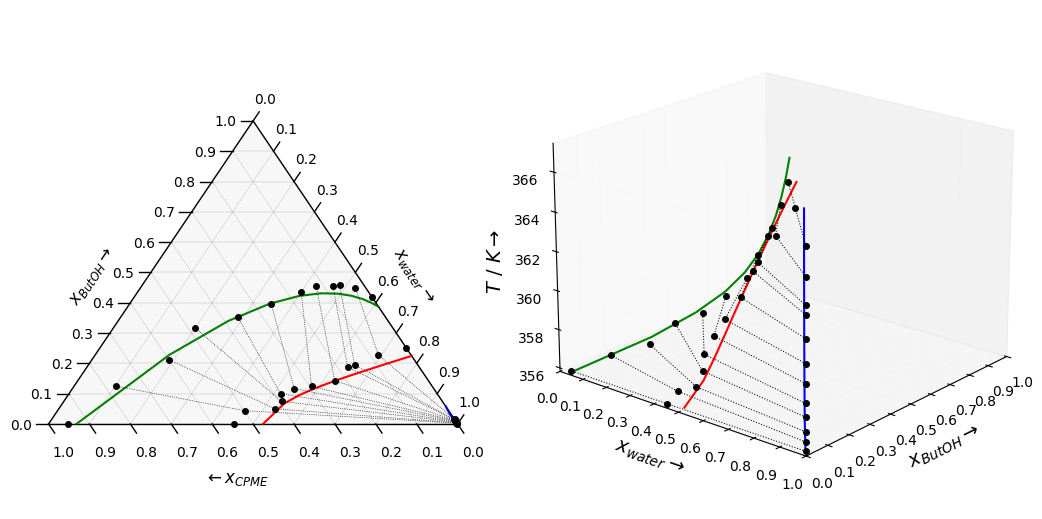

In [42]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import ternary
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import Axes3D

# Experimental Data
Texp = np.array([365.77, 364.32, 362.99, 362.54, 361.41, 360.22, 359.27, 358.33, 357.67, 356.97, 356.48, 356.05])

Xexp = np.array([[0.983,  0.985,  0.987,  0.987,  0.988,  0.989,  0.991,  0.992,  0.993,  0.995,  0.996,  0.999],
                 [0.017,  0.015,  0.013,  0.013,  0.012,  0.011,  0.009,  0.007,  0.006,  0.004,  0.003,  0.000],
                 [0.000,  0.000,  2e-5,   3e-5,   3e-5,   4e-4,   8e-5,   0.001,  0.001,  0.001,  0.001,  0.001]])
Wexp = np.array([[0.580,  0.525,  0.483,  0.467,  0.426,  0.400,  0.347,  0.286,  0.201,  0.188,  0.102,  0.048],
                 [0.420,  0.450,  0.457,  0.456,  0.456,  0.435,  0.395,  0.353,  0.316,  0.212,  0.125,  0.000],
                 [0.000,  0.025,  0.06,   0.077,  0.118,  0.165,  0.258,  0.361,  0.483,  0.600,  0.773,  0.952]])
Yexp = np.array([[0.749,  0.693,  0.65,   0.637,  0.628,  0.581,  0.542,  0.517,  0.532,  0.529,  0.457,  0.453],
                 [0.251,  0.227,  0.196,  0.188,  0.143,  0.124,  0.117,  0.100,  0.075,  0.050,  0.044,  0.000],
                 [0.000,  0.080,  0.154,  0.175,  0.229,  0.295,  0.341,  0.383,  0.393,  0.421,  0.499,  0.547]])

fig = plt.figure(figsize = (10,5), constrained_layout=True)
plt.rcParams['grid.linewidth'] = 0.01
# -------------------------------------------------------------------------------------------
# PLOT 1 non isothermal xyw triangular diagram
# -------------------------------------------------------------------------------------------
ax1 = fig.add_subplot(121)
tax = ternary.TernaryAxesSubplot(ax=ax1, scale = 1)
tax.boundary(linewidth=1.0)
tax.gridlines(color="black", multiple=0.1, linewidth=0.2)
# Set ticks
tax.ticks(clockwise=True, multiple=0.1, linewidth=1, offset = 0.03, tick_formats='%.1f')
#Set component labels
tax.right_axis_label(r"$x_{water}\rightarrow$", fontsize=12, offset = 0.15)
tax.left_axis_label(r"$x_{ButOH} \rightarrow$", fontsize=12, offset = 0.15)
tax.bottom_axis_label(r"$\leftarrow x_{CPME}$", fontsize=12, offset = 0.15)
# Remove default Matplotlib Axes
tax.clear_matplotlib_ticks()
tax._redraw_labels()
ax1.set_axis_off()
# -------------------------------------------------------------------------------------------
# plot the VLLE results obtanined by SAFT-VR Mie in the previous code-block
tax.plot(x, color = 'b')
tax.plot(w, color = 'g')
tax.plot(y, color = 'r')
# -------------------------------------------------------------------------------------------
# Plot the experimental Tie-Lines
for i in range(0,len(Texp)):
    tax.plot([Xexp.transpose()[i], Yexp.transpose()[i], Wexp.transpose()[i]], marker='o', markersize=4, linestyle='dotted', color='k', linewidth=0.5)
# -------------------------------------------------------------------------------------------
# PLOT 2 Txyw 3D diagram
# -------------------------------------------------------------------------------------------
ax2 = fig.add_subplot(122, projection='3d')
ax2.view_init(20, -50)      # This can be touched
ax2.axes.set_xlim3d(left=0, right=1)
ax2.axes.set_ylim3d(bottom=0, top=1)
ax2.set_xticks(np.arange(0,1.1,0.1), minor=False)
ax2.set_yticks(np.arange(0,1.1,0.1), minor=False)
ax2.set_xlabel(r"$x_{water}\rightarrow$", fontsize=14)
ax2.set_ylabel(r"$x_{ButOH}\rightarrow$", fontsize=14)
ax2.set_zlabel(r"$T\ /\ K\rightarrow$", fontsize=14, rotation=90)
ax2.zaxis.set_rotate_label(False)  # disable automatic rotation
tmp_planes = ax2.zaxis._PLANES
ax2.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3],
                     tmp_planes[0], tmp_planes[1],
                     tmp_planes[4], tmp_planes[5])

# -------------------------------------------------------------------------------------------
# plot the VLLE results obtanined by SAFT-VR Mie in the previous code-block
ax2.plot(x[:,0], x[:,1], T, label='Tri_AC',color='b', linewidth=1.5 )
ax2.plot(w[:,0], w[:,1], T, label='Tri_Org',color='g', linewidth=1.5)
ax2.plot(y[:,0], y[:,1], T, label='Tri_Vap',color='r', linewidth=1.5)
# -------------------------------------------------------------------------------------------
# Plot the experimental Tie-Lines
for i in range(len(Texp)):
    ax2.plot([Xexp[0,i], Yexp[0,i], Wexp[0,i]], [Xexp[1,i], Yexp[1,i], Wexp[1,i]], [Texp[i], Texp[i], Texp[i]],
            label='exp', color='k', marker='o', markersize=4, linestyle='dotted', linewidth=0.75)
# -------------------------------------------------------------------------------------------
ax1.set_position([0, 0.1, 0.45, 0.7])  # Make it smaller and shifted to the left
ax2.set_position([0.4, 0, 0.7, 1])     # Make it bigger and shifted to the right